<!-- # Giovani Verotti RA: 770265 -->


<!--  -->

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import pandas as pd

<!-- ## Passo 1: Criar Dicionário -->

In [2]:
distrib = {
    'Normal': {
        'Params': {'Loc':0, 'Scale':1}, 'Dados': None,
        'Estatistica': {
            'Média': None,
            'Mediana': None,
            'DP': None,
            'Variância': None
        }
    },
    
    'Exponencial': {
        'Params': {'Scale':2}, 'Dados': None,
        'Estatistica': {
            'Média': None,
            'Mediana': None,
            'DP': None,
            'Variância': None
        }
    },
    
    'Uniforme': {
        'Params': {'Low':-1, 'High':1}, 'Dados': None,
        'Estatistica': {
            'Média': None,
            'Mediana': None,
            'DP': None,
            'Variância': None
        }
    }

}

distrib

{'Normal': {'Params': {'Loc': 0, 'Scale': 1},
  'Dados': None,
  'Estatistica': {'Média': None,
   'Mediana': None,
   'DP': None,
   'Variância': None}},
 'Exponencial': {'Params': {'Scale': 2},
  'Dados': None,
  'Estatistica': {'Média': None,
   'Mediana': None,
   'DP': None,
   'Variância': None}},
 'Uniforme': {'Params': {'Low': -1, 'High': 1},
  'Dados': None,
  'Estatistica': {'Média': None,
   'Mediana': None,
   'DP': None,
   'Variância': None}}}

<!-- ## Passo 2: Importar Bibliotecas -->


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import polars as pl

<!-- ## Passo 3: Gerar Dados -->

In [4]:
norm = np.random.normal(0,1,1000)
exp = np.random.exponential(2,1000)
unif = np.random.uniform(-1,1,1000)


dados_gerados = {
    'Normal': norm,
    'Exponencial': exp,
    'Uniforme': unif
}

dados_gerados


{'Normal': array([-1.29617726e+00,  1.88013022e+00, -7.05168802e-01, -7.54519867e-01,
         8.19603997e-01,  2.57757929e-01,  6.08051825e-01,  1.39304559e+00,
        -1.50720026e+00,  1.82754930e-01,  8.61470742e-01,  1.18738068e+00,
         5.51991485e-01,  8.22834609e-02, -1.89171361e+00,  1.77840306e+00,
        -1.30066314e+00,  9.73997504e-01,  4.51125935e-01, -1.85866183e-01,
         2.08630310e+00, -7.32705719e-01,  1.08031427e+00, -1.64679194e+00,
         1.78721997e+00, -2.95909971e-01,  1.08672982e+00, -1.62350800e+00,
         1.70882098e+00,  5.17363535e-01, -6.02183340e-01,  4.72343332e-01,
         6.56449502e-01, -1.17415924e+00, -8.17278397e-01, -1.08729818e-01,
        -1.92361755e+00,  9.20659155e-01, -1.73071213e-01, -4.37871843e-01,
        -7.60936354e-02, -5.94725156e-01, -7.96249997e-01, -3.16809576e+00,
        -1.23038676e+00, -1.04496749e+00,  1.55565994e+00, -7.60698670e-01,
        -1.11682961e-01,  1.56751117e-01, -3.29656266e-01,  1.08733784e+00,
  

In [5]:
for nome in distrib.keys():
    distrib[nome]['Dados'] = dados_gerados[nome]

distrib

{'Normal': {'Params': {'Loc': 0, 'Scale': 1},
  'Dados': array([-1.29617726e+00,  1.88013022e+00, -7.05168802e-01, -7.54519867e-01,
          8.19603997e-01,  2.57757929e-01,  6.08051825e-01,  1.39304559e+00,
         -1.50720026e+00,  1.82754930e-01,  8.61470742e-01,  1.18738068e+00,
          5.51991485e-01,  8.22834609e-02, -1.89171361e+00,  1.77840306e+00,
         -1.30066314e+00,  9.73997504e-01,  4.51125935e-01, -1.85866183e-01,
          2.08630310e+00, -7.32705719e-01,  1.08031427e+00, -1.64679194e+00,
          1.78721997e+00, -2.95909971e-01,  1.08672982e+00, -1.62350800e+00,
          1.70882098e+00,  5.17363535e-01, -6.02183340e-01,  4.72343332e-01,
          6.56449502e-01, -1.17415924e+00, -8.17278397e-01, -1.08729818e-01,
         -1.92361755e+00,  9.20659155e-01, -1.73071213e-01, -4.37871843e-01,
         -7.60936354e-02, -5.94725156e-01, -7.96249997e-01, -3.16809576e+00,
         -1.23038676e+00, -1.04496749e+00,  1.55565994e+00, -7.60698670e-01,
         -1.11682961e

<!-- ## Passo 4: Calcular Estatistísticas Básicas -->

In [6]:
for nome in distrib.keys():
    distrib[nome]['Estatistica']['Média'] = np.mean(distrib[nome]['Dados'])
    distrib[nome]['Estatistica']['Mediana'] = np.median(distrib[nome]['Dados']) 
    distrib[nome]['Estatistica']['DP'] = 0.5*np.var(distrib[nome]['Dados']) 
    distrib[nome]['Estatistica']['Variância'] = np.var(distrib[nome]['Dados']) 

distrib

{'Normal': {'Params': {'Loc': 0, 'Scale': 1},
  'Dados': array([-1.29617726e+00,  1.88013022e+00, -7.05168802e-01, -7.54519867e-01,
          8.19603997e-01,  2.57757929e-01,  6.08051825e-01,  1.39304559e+00,
         -1.50720026e+00,  1.82754930e-01,  8.61470742e-01,  1.18738068e+00,
          5.51991485e-01,  8.22834609e-02, -1.89171361e+00,  1.77840306e+00,
         -1.30066314e+00,  9.73997504e-01,  4.51125935e-01, -1.85866183e-01,
          2.08630310e+00, -7.32705719e-01,  1.08031427e+00, -1.64679194e+00,
          1.78721997e+00, -2.95909971e-01,  1.08672982e+00, -1.62350800e+00,
          1.70882098e+00,  5.17363535e-01, -6.02183340e-01,  4.72343332e-01,
          6.56449502e-01, -1.17415924e+00, -8.17278397e-01, -1.08729818e-01,
         -1.92361755e+00,  9.20659155e-01, -1.73071213e-01, -4.37871843e-01,
         -7.60936354e-02, -5.94725156e-01, -7.96249997e-01, -3.16809576e+00,
         -1.23038676e+00, -1.04496749e+00,  1.55565994e+00, -7.60698670e-01,
         -1.11682961e

<!-- ## Passo 5: Histogramas -->

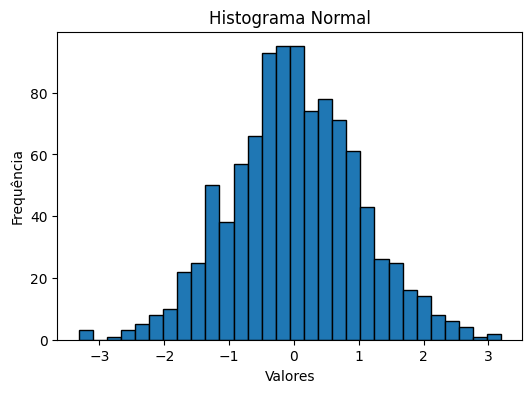

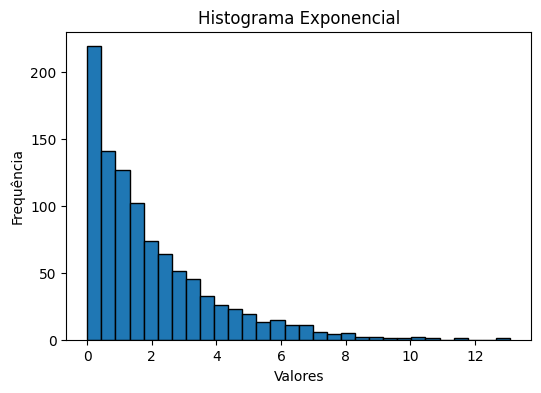

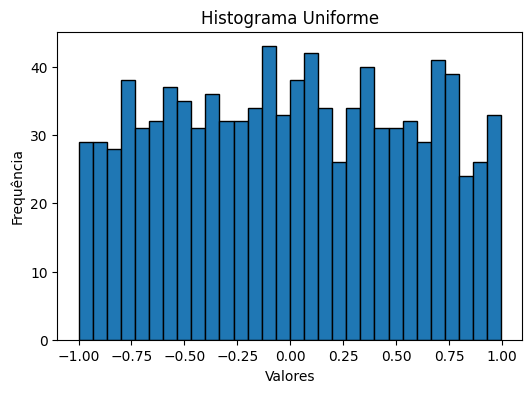

In [7]:
for nome in distrib.keys():
    plt.figure(figsize=(6,4))
    plt.hist(
        distrib[nome]['Dados'], bins=30, edgecolor = 'black'
    )
    plt.title(f'Histograma {nome}')
    plt.xlabel('Valores')
    plt.ylabel('Frequência')
    


<!-- ## Passo 6: Organizar Resultado em Pandas -->

In [8]:
data_pd = (
    pd.DataFrame({
        nome: distrib[nome]['Estatistica'] 
         for nome in distrib.keys()
         })
)

data_pd

,Normal,Exponencial,Uniforme
Média,0.015671,1.975262,-0.001422
Mediana,-0.007380,1.386456,-0.003993
DP,0.491368,1.905090,0.157930
Variância,0.982736,3.810180,0.315861


<!-- ## Passo 7: Adicionar Novas Distribuicoes -->

In [9]:
distrib['Poisson'] = {
    'Params': {'Lambda': 3},
    'Dados': np.random.poisson(lam=3, size=1000),
    'Estatistica': {'Média':None, 'Mediana':None, 'DP':None, 'Variância':None}
}

distrib['Binomial'] = {
    'Params': {'p': 0.8, 'n' : 5},
    'Dados': np.random.binomial(p=0.8,n=5, size=1000),
    'Estatistica': {'Média':None, 'Mediana':None, 'DP':None, 'Variância':None}
}




distrib

{'Normal': {'Params': {'Loc': 0, 'Scale': 1},
  'Dados': array([-1.29617726e+00,  1.88013022e+00, -7.05168802e-01, -7.54519867e-01,
          8.19603997e-01,  2.57757929e-01,  6.08051825e-01,  1.39304559e+00,
         -1.50720026e+00,  1.82754930e-01,  8.61470742e-01,  1.18738068e+00,
          5.51991485e-01,  8.22834609e-02, -1.89171361e+00,  1.77840306e+00,
         -1.30066314e+00,  9.73997504e-01,  4.51125935e-01, -1.85866183e-01,
          2.08630310e+00, -7.32705719e-01,  1.08031427e+00, -1.64679194e+00,
          1.78721997e+00, -2.95909971e-01,  1.08672982e+00, -1.62350800e+00,
          1.70882098e+00,  5.17363535e-01, -6.02183340e-01,  4.72343332e-01,
          6.56449502e-01, -1.17415924e+00, -8.17278397e-01, -1.08729818e-01,
         -1.92361755e+00,  9.20659155e-01, -1.73071213e-01, -4.37871843e-01,
         -7.60936354e-02, -5.94725156e-01, -7.96249997e-01, -3.16809576e+00,
         -1.23038676e+00, -1.04496749e+00,  1.55565994e+00, -7.60698670e-01,
         -1.11682961e

In [10]:
for nome in distrib.keys():
    distrib[nome]['Estatistica']['Média'] = np.mean(distrib[nome]['Dados'])
    distrib[nome]['Estatistica']['Mediana'] = np.median(distrib[nome]['Dados']) 
    distrib[nome]['Estatistica']['DP'] = 0.5**np.var(distrib[nome]['Dados']) 
    distrib[nome]['Estatistica']['Variância'] = np.var(distrib[nome]['Dados']) 

distrib

{'Normal': {'Params': {'Loc': 0, 'Scale': 1},
  'Dados': array([-1.29617726e+00,  1.88013022e+00, -7.05168802e-01, -7.54519867e-01,
          8.19603997e-01,  2.57757929e-01,  6.08051825e-01,  1.39304559e+00,
         -1.50720026e+00,  1.82754930e-01,  8.61470742e-01,  1.18738068e+00,
          5.51991485e-01,  8.22834609e-02, -1.89171361e+00,  1.77840306e+00,
         -1.30066314e+00,  9.73997504e-01,  4.51125935e-01, -1.85866183e-01,
          2.08630310e+00, -7.32705719e-01,  1.08031427e+00, -1.64679194e+00,
          1.78721997e+00, -2.95909971e-01,  1.08672982e+00, -1.62350800e+00,
          1.70882098e+00,  5.17363535e-01, -6.02183340e-01,  4.72343332e-01,
          6.56449502e-01, -1.17415924e+00, -8.17278397e-01, -1.08729818e-01,
         -1.92361755e+00,  9.20659155e-01, -1.73071213e-01, -4.37871843e-01,
         -7.60936354e-02, -5.94725156e-01, -7.96249997e-01, -3.16809576e+00,
         -1.23038676e+00, -1.04496749e+00,  1.55565994e+00, -7.60698670e-01,
         -1.11682961e

In [11]:
data_pd = (
    pd.DataFrame({
        nome: distrib[nome]['Estatistica'] 
         for nome in distrib.keys()
         })
)

data_pd

,Normal,Exponencial,Uniforme,Poisson,Binomial
Média,0.015671,1.975262,-0.001422,3.076000,3.958000
Mediana,-0.007380,1.386456,-0.003993,3.000000,4.000000
DP,0.506019,0.071289,0.803371,0.115006,0.556234
Variância,0.982736,3.810180,0.315861,3.120224,0.846236


<!-- ## Passo 8: Estatisticas Adicionais -->


In [12]:
for nome in distrib.keys():
    
    dados = distrib[nome]['Dados']

    distrib[nome]['Estatistica']['Minimo'] = np.min(dados)
    distrib[nome]['Estatistica']['Maximo'] = np.max(dados)
    distrib[nome]['Estatistica']['Q1'] = np.percentile(dados, 0.25)
    distrib[nome]['Estatistica']['Q2'] = np.percentile(dados, 0.5)
    distrib[nome]['Estatistica']['Q3'] = np.percentile(dados, 0.75)

distrib


{'Normal': {'Params': {'Loc': 0, 'Scale': 1},
  'Dados': array([-1.29617726e+00,  1.88013022e+00, -7.05168802e-01, -7.54519867e-01,
          8.19603997e-01,  2.57757929e-01,  6.08051825e-01,  1.39304559e+00,
         -1.50720026e+00,  1.82754930e-01,  8.61470742e-01,  1.18738068e+00,
          5.51991485e-01,  8.22834609e-02, -1.89171361e+00,  1.77840306e+00,
         -1.30066314e+00,  9.73997504e-01,  4.51125935e-01, -1.85866183e-01,
          2.08630310e+00, -7.32705719e-01,  1.08031427e+00, -1.64679194e+00,
          1.78721997e+00, -2.95909971e-01,  1.08672982e+00, -1.62350800e+00,
          1.70882098e+00,  5.17363535e-01, -6.02183340e-01,  4.72343332e-01,
          6.56449502e-01, -1.17415924e+00, -8.17278397e-01, -1.08729818e-01,
         -1.92361755e+00,  9.20659155e-01, -1.73071213e-01, -4.37871843e-01,
         -7.60936354e-02, -5.94725156e-01, -7.96249997e-01, -3.16809576e+00,
         -1.23038676e+00, -1.04496749e+00,  1.55565994e+00, -7.60698670e-01,
         -1.11682961e

In [13]:
data_pd = (
    pd.DataFrame({
        nome: distrib[nome]['Estatistica'] 
         for nome in distrib.keys()
         })
)

data_pd

,Normal,Exponencial,Uniforme,Poisson,Binomial
Média,0.015671,1.975262,-0.001422,3.076000,3.958000
Mediana,-0.007380,1.386456,-0.003993,3.000000,4.000000
DP,0.506019,0.071289,0.803371,0.115006,0.556234
Variância,0.982736,3.810180,0.315861,3.120224,0.846236
Minimo,-3.322730,0.001005,-0.999823,0.000000,1.000000
Maximo,3.198971,13.090096,0.996053,10.000000,5.000000
Q1,-2.986532,0.002616,-0.993492,0.000000,1.000000
Q2,-2.515953,0.003526,-0.986924,0.000000,1.000000
Q3,-2.427771,0.009464,-0.982919,0.000000,1.492500


<!-- ## Passo 9: Comparar Distrib Graficamente -->


C:\Users\Giovani\AppData\Local\Temp\ipykernel_18172\1142750433.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_box.values, labels=data_pd.columns)


(array([1, 2, 3, 4, 5]),
 [Text(1, 0, 'Normal'),
  Text(2, 0, 'Exponencial'),
  Text(3, 0, 'Uniforme'),
  Text(4, 0, 'Poisson'),
  Text(5, 0, 'Binomial')])

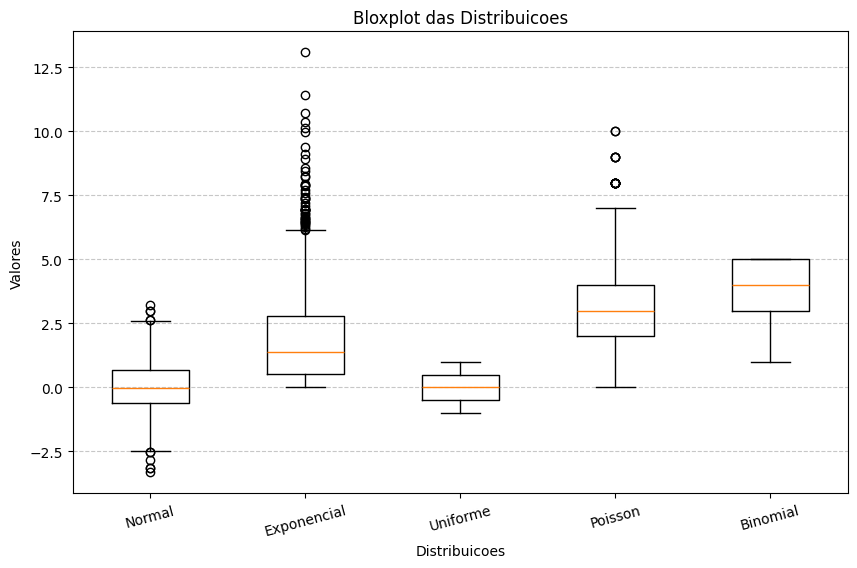

In [ ]:
data_box = (
    pd.DataFrame({
        nome: distrib[nome]['Dados']
         for nome in distrib.keys()
         })
)


plt.figure(figsize=(10,6))
plt.boxplot(data_box.values, labels=data_pd.columns)
plt.title('Bloxplot das Distribuicoes')
plt.xlabel('Distribuicoes')
plt.ylabel('Valores')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=15)


<!-- ## Passo 10: Comparar estatísticas calculadas com valores teóricos -->

In [15]:
distrib


{'Normal': {'Params': {'Loc': 0, 'Scale': 1},
  'Dados': array([-1.29617726e+00,  1.88013022e+00, -7.05168802e-01, -7.54519867e-01,
          8.19603997e-01,  2.57757929e-01,  6.08051825e-01,  1.39304559e+00,
         -1.50720026e+00,  1.82754930e-01,  8.61470742e-01,  1.18738068e+00,
          5.51991485e-01,  8.22834609e-02, -1.89171361e+00,  1.77840306e+00,
         -1.30066314e+00,  9.73997504e-01,  4.51125935e-01, -1.85866183e-01,
          2.08630310e+00, -7.32705719e-01,  1.08031427e+00, -1.64679194e+00,
          1.78721997e+00, -2.95909971e-01,  1.08672982e+00, -1.62350800e+00,
          1.70882098e+00,  5.17363535e-01, -6.02183340e-01,  4.72343332e-01,
          6.56449502e-01, -1.17415924e+00, -8.17278397e-01, -1.08729818e-01,
         -1.92361755e+00,  9.20659155e-01, -1.73071213e-01, -4.37871843e-01,
         -7.60936354e-02, -5.94725156e-01, -7.96249997e-01, -3.16809576e+00,
         -1.23038676e+00, -1.04496749e+00,  1.55565994e+00, -7.60698670e-01,
         -1.11682961e

In [16]:
for nome in distrib.keys():
    
    est = distrib[nome]['Estatistica']
    params = distrib[nome]['Params']

    est['media_amostra'] = est.pop('Média')
    est['mediana_amostra'] = est.pop('Mediana')
    est['dp_amostra'] = est.pop('DP')
    est['var_amostra'] = est.pop('Variância')
    est['Minimo_amostra'] = est.pop('Minimo')
    est['Maximo_amostra'] = est.pop('Maximo')
    est['Q1_amostra'] = est.pop('Q1')
    est['Q2_amostra'] = est.pop('Q2')
    est['Q3_amostra'] = est.pop('Q3')

    if nome == 'Normal':
        est['media_teorico'] = params['Loc']
        est['mediana_teorico'] = params['Loc']
        est['dp_teorico'] = params['Scale']
        est['var_teorico'] = params['Scale']**2

    elif nome == 'Exponencial':
        est['media_teorico'] = params['Scale']
        est['mediana_toerico'] = params['Scale'] * np.log(2)
        est['dp_teorico'] = params['Scale']
        est['var_teorico'] = params['Scale']**2
    
    elif nome == 'Uniforme':
        a = params['Low']
        b = params['High']
        est['media_teorico'] = (a + b)/2
        est['mediana_toerico'] = (a + b)/2
        est['var_teorico'] = ((b - a)**2)/12
        est['dp_teorico'] = est['var_teorico']**0.5

    elif nome == 'Poisson':
        lam = params['Lambda']
        est['media_teorico'] = lam
        est['mediana_toerico'] = None
        est['var_teorico'] = lam
        est['dp_teorico'] = est['var_teorico']**0.5
      
    elif nome == 'Binomial':
        n = params['n']
        p = params['p']
        est['media_teorico'] = n*p
        est['mediana_toerico'] = None
        est['var_teorico'] = n*p*(1-p)
        est['dp_teorico'] = est['var_teorico']**0.5


    

In [18]:
distrib

{'Normal': {'Params': {'Loc': 0, 'Scale': 1},
  'Dados': array([-1.29617726e+00,  1.88013022e+00, -7.05168802e-01, -7.54519867e-01,
          8.19603997e-01,  2.57757929e-01,  6.08051825e-01,  1.39304559e+00,
         -1.50720026e+00,  1.82754930e-01,  8.61470742e-01,  1.18738068e+00,
          5.51991485e-01,  8.22834609e-02, -1.89171361e+00,  1.77840306e+00,
         -1.30066314e+00,  9.73997504e-01,  4.51125935e-01, -1.85866183e-01,
          2.08630310e+00, -7.32705719e-01,  1.08031427e+00, -1.64679194e+00,
          1.78721997e+00, -2.95909971e-01,  1.08672982e+00, -1.62350800e+00,
          1.70882098e+00,  5.17363535e-01, -6.02183340e-01,  4.72343332e-01,
          6.56449502e-01, -1.17415924e+00, -8.17278397e-01, -1.08729818e-01,
         -1.92361755e+00,  9.20659155e-01, -1.73071213e-01, -4.37871843e-01,
         -7.60936354e-02, -5.94725156e-01, -7.96249997e-01, -3.16809576e+00,
         -1.23038676e+00, -1.04496749e+00,  1.55565994e+00, -7.60698670e-01,
         -1.11682961e

In [ ]:
comparacao = (
    pd.DataFrame({
        nome: distrib[nome]['Estatistica']
         for nome in distrib.keys()
         })
).T

comparacao[[
    'media_amostra' , 'media_teorico' , 'mediana_amostra' , 'mediana_teorico',
    'dp_amostra' , 'dp_teorico' , 'var_amostra' , 'var_teorico'
]]





,media_amostra,media_teorico,mediana_amostra,mediana_teorico,dp_amostra,dp_teorico,var_amostra,var_teorico
Normal,0.015671,0.0,-0.007380,0.0,0.506019,1.000000,0.982736,1.000000
Exponencial,1.975262,2.0,1.386456,NaN,0.071289,2.000000,3.810180,4.000000
Uniforme,-0.001422,0.0,-0.003993,NaN,0.803371,0.577350,0.315861,0.333333
Poisson,3.076000,3.0,3.000000,NaN,0.115006,1.732051,3.120224,3.000000
Binomial,3.958000,4.0,4.000000,NaN,0.556234,0.894427,0.846236,0.800000


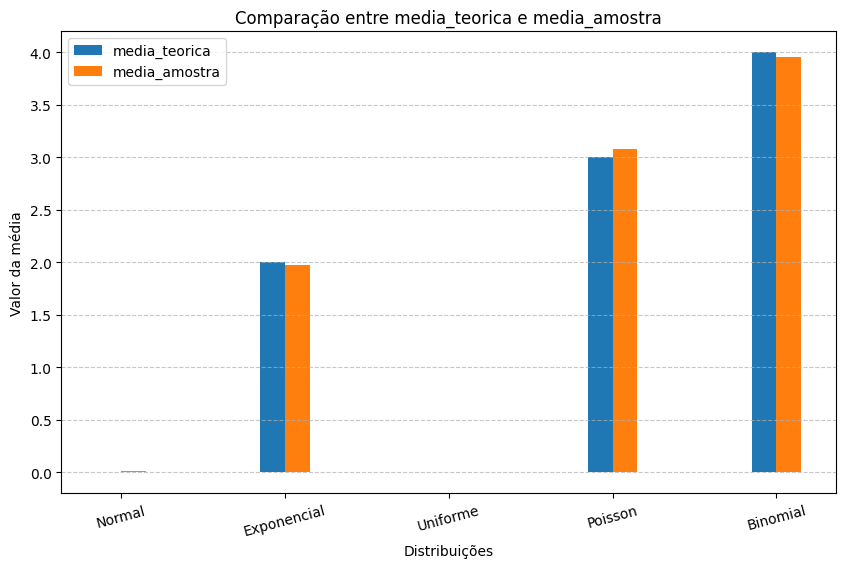

In [38]:
media_amostra = [
    distrib[nome]['Estatistica']['media_amostra'] for nome in distrib.keys()
]

media_teorica = [
    distrib[nome]['Estatistica']['media_teorico'] for nome in distrib.keys()
]

x = np.arange(len(nomes))

largura = 0.15


plt.figure(figsize=(10,6))

plt.bar(x - largura/2, media_teorica, width=largura, label='media_teorica')
plt.bar(x + largura/2, media_amostra, width=largura, label='media_amostra')

plt.xticks(x, nomes, rotation=15)
plt.title('Comparação entre media_teorica e media_amostra')
plt.xlabel('Distribuições')
plt.ylabel('Valor da média')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()